<b><font size="6">Classification | Stroke Risk Prediction</font></b>

* **Purpose**: Build and evaluate 3 classification models to predict stroke risk
* **Target**: `stroke` (0 = No Stroke, 1 = Stroke)
* **Models**: Logistic Regression, K-Nearest Neighbours, XGBoost
* **Note**: Models were trained and tuned in `src/train_models.py`. This notebook loads the saved models and analyses their results.

# 1. Importing Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Load Data

The models were already trained in `src/train_models.py` and saved to `artifacts/`. Here we load the test data and the saved models for evaluation.

- **Scaled data** is used for Logistic Regression and KNN — these algorithms are sensitive to feature scale.
- **Unscaled data** is used for XGBoost — tree-based models are scale invariant.

In [47]:
data_dir = 'data/processed'

# Unscaled - for XGBoost
X_train = pd.read_csv(os.path.join(data_dir, 'X_train.csv'))
X_test  = pd.read_csv(os.path.join(data_dir, 'X_test.csv'))

# Scaled - for Logistic Regression and KNN
X_train_scaled = pd.read_csv(os.path.join(data_dir, 'X_train_scaled.csv'))
X_test_scaled  = pd.read_csv(os.path.join(data_dir, 'X_test_scaled.csv'))

# Target labels
y_train = pd.read_csv(os.path.join(data_dir, 'y_train.csv'))['stroke']
y_test  = pd.read_csv(os.path.join(data_dir, 'y_test.csv'))['stroke']

# Convert boolean columns to int for sklearn compatibility
bool_cols = X_train.select_dtypes(include='bool').columns.tolist()
for df in [X_train, X_test, X_train_scaled, X_test_scaled]:
    df[bool_cols] = df[bool_cols].astype(int)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape:     {X_test.shape}")
print(f"Test target distribution:")
print(y_test.value_counts())

Training set shape: (6806, 15)
Test set shape:     (767, 15)
Test target distribution:
stroke
0    729
1     38
Name: count, dtype: int64


## 2.1 Load Trained Models

Models were trained with GridSearchCV hyperparameter tuning in `src/train_models.py` and saved using `joblib`. We load the best estimators here.

In [48]:
# Load the best estimators saved after GridSearchCV tuning
lr_model  = joblib.load('artifacts/model_lr.pkl')
knn_model = joblib.load('artifacts/model_knn.pkl')
xgb_model = joblib.load('artifacts/model_xgb.pkl')

print("All three models loaded from artifacts/")

All three models loaded from artifacts/


# 3. Model 1: Logistic Regression

Logistic Regression predicts the probability of a binary outcome — in this case, whether a patient will have a stroke — using a linear decision boundary. It is the standard baseline model for binary classification.

**Key setting:** `class_weight='balanced'` ensures neither class is favoured during training, which is important since stroke cases are rare even after upsampling.

**Best hyperparameters found by GridSearchCV:** C=1, solver=liblinear

LOGISTIC REGRESSION PERFORMANCE:
  Training Accuracy:  0.7827
  Test Accuracy:      0.7262
  Test Precision:     0.1325
  Test Recall:        0.8158
  Test F1-Score:      0.2279
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.72      0.83       729
           1       0.13      0.82      0.23        38

    accuracy                           0.73       767
   macro avg       0.56      0.77      0.53       767
weighted avg       0.94      0.73      0.80       767



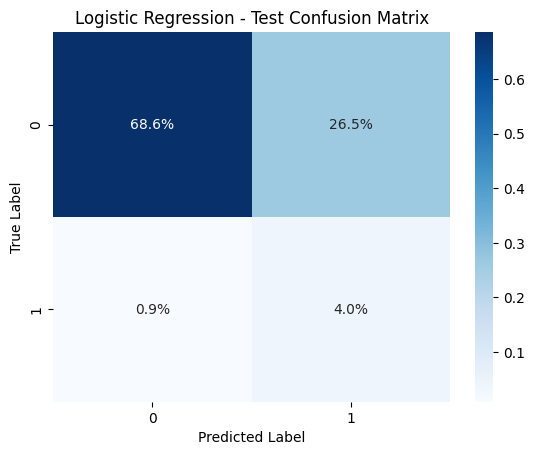

In [49]:
# Generate predictions using the trained logistic regression model
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr  = lr_model.predict(X_test_scaled)

print("LOGISTIC REGRESSION PERFORMANCE:")
print(f"  Training Accuracy:  {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"  Test Accuracy:      {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"  Test Precision:     {precision_score(y_test, y_test_pred_lr, zero_division=0):.4f}")
print(f"  Test Recall:        {recall_score(y_test, y_test_pred_lr, zero_division=0):.4f}")
print(f"  Test F1-Score:      {f1_score(y_test, y_test_pred_lr, zero_division=0):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_test_pred_lr))

# Confusion matrix — shows correct vs incorrect predictions per class
cm = confusion_matrix(y_test, y_test_pred_lr)
sns.heatmap(cm / np.sum(cm), annot=True, cmap='Blues', fmt='.1%')
plt.title('Logistic Regression - Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Logistic Regression achieves 72.6% test accuracy with a recall of **0.82** , the highest of all three models. This means it correctly identifies 82% of actual stroke cases, making it the strongest model by the metric that matters most in this context. The trade-off is low precision (0.13): the model raises many false alarms, flagging non-stroke patients as at risk. In a medical screening setting, this is an acceptable trade-off which is a missed stroke is clinically far more dangerous than an unnecessary follow-up. The train-test accuracy gap (0.78 vs 0.73) is within acceptable bounds, indicating the model generalises without significant overfitting.

Feature Coefficients (Logistic Regression):
                       Feature  Coefficient
                           age     1.892800
            work_type_children     1.264988
                  hypertension     0.446547
         smoking_status_smokes     0.396239
                 heart_disease     0.325698
             avg_glucose_level     0.253048
smoking_status_formerly smoked     0.163657
                Residence_type     0.069644
                           bmi     0.018779
             work_type_Private    -0.060255
        work_type_Never_worked    -0.067837
                  ever_married    -0.183972
       work_type_Self-employed    -0.186256
                        gender    -0.194678
   smoking_status_never smoked    -0.198724


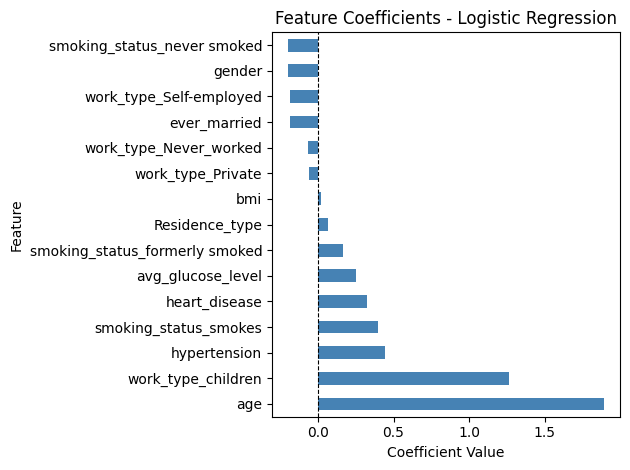

In [50]:
# Coefficients show which features push the prediction toward stroke (positive) or away (negative)
lr_coefs = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Feature Coefficients (Logistic Regression):")
print(lr_coefs.to_string(index=False))

lr_coefs.plot(kind='barh', x='Feature', y='Coefficient', color='steelblue', legend=False)
plt.title('Feature Coefficients - Logistic Regression')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

Features with **positive coefficients** increase the predicted probability of stroke. Features with **negative coefficients** reduce it. Age, hypertension, heart disease, and average glucose level are expected to be the strongest positive predictors, which aligns with clinical knowledge about stroke risk factors.

# 4. Model 2: K-Nearest Neighbours (KNN)

KNN classifies a new patient by finding the K most similar patients in the training data and taking a majority vote on their stroke outcome. It requires scaled data because it relies on distance — features with larger ranges would otherwise dominate the calculation.

**Best hyperparameters found by GridSearchCV:** n_neighbors=3, weights=distance

KNN PERFORMANCE:
  Training Accuracy:  1.0000
  Test Accuracy:      0.8774
  Test Precision:     0.0758
  Test Recall:        0.1316
  Test F1-Score:      0.0962
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       729
           1       0.08      0.13      0.10        38

    accuracy                           0.88       767
   macro avg       0.51      0.52      0.52       767
weighted avg       0.91      0.88      0.89       767



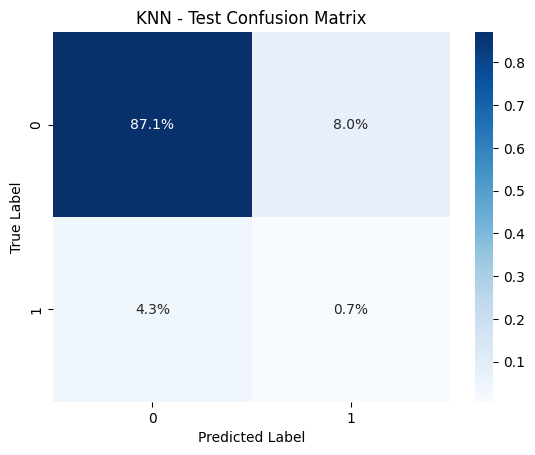

In [52]:
# Generate predictions using the trained KNN model
y_train_pred_knn = knn_model.predict(X_train_scaled)
y_test_pred_knn  = knn_model.predict(X_test_scaled)

print("KNN PERFORMANCE:")
print(f"  Training Accuracy:  {accuracy_score(y_train, y_train_pred_knn):.4f}")
print(f"  Test Accuracy:      {accuracy_score(y_test, y_test_pred_knn):.4f}")
print(f"  Test Precision:     {precision_score(y_test, y_test_pred_knn, zero_division=0):.4f}")
print(f"  Test Recall:        {recall_score(y_test, y_test_pred_knn, zero_division=0):.4f}")
print(f"  Test F1-Score:      {f1_score(y_test, y_test_pred_knn, zero_division=0):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_test_pred_knn))

cm = confusion_matrix(y_test, y_test_pred_knn)
sns.heatmap(cm / np.sum(cm), annot=True, cmap='Blues', fmt='.1%')
plt.title('KNN - Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

KNN achieves 87.7% test accuracy but a recall of only **0.13** — it correctly identifies just 5 of the 38 actual stroke cases in the test set. This makes it the weakest model for this use case. The training accuracy of 1.0 combined with a test gap of 0.12 also exceeds the 0.10 overfitting threshold, suggesting the model has memorised training patterns rather than learning generalisable ones. KNN is not recommended for stroke prediction given this recall performance.

# 5. Model 3: XGBoost Classifier

XGBoost builds decision trees sequentially — each new tree corrects the errors of the previous one. It is one of the strongest classification algorithms and does not require feature scaling.

**Best hyperparameters found by GridSearchCV:** learning_rate=0.2, max_depth=8, n_estimators=200

XGBOOST PERFORMANCE:
  Training Accuracy:  1.0000
  Test Accuracy:      0.9400
  Test Precision:     0.3000
  Test Recall:        0.1579
  Test F1-Score:      0.2069
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       729
           1       0.30      0.16      0.21        38

    accuracy                           0.94       767
   macro avg       0.63      0.57      0.59       767
weighted avg       0.92      0.94      0.93       767



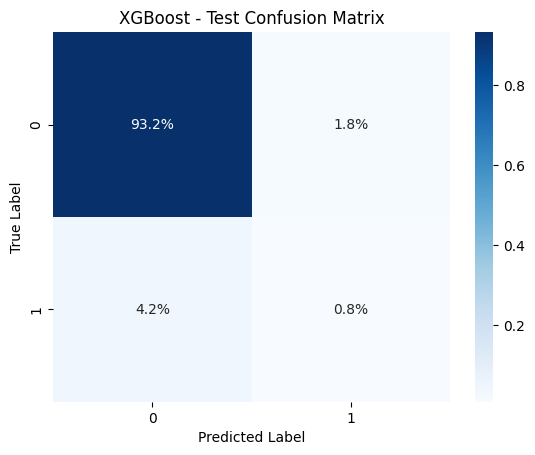

In [53]:
# Generate predictions using the trained XGBoost model
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb  = xgb_model.predict(X_test)

print("XGBOOST PERFORMANCE:")
print(f"  Training Accuracy:  {accuracy_score(y_train, y_train_pred_xgb):.4f}")
print(f"  Test Accuracy:      {accuracy_score(y_test, y_test_pred_xgb):.4f}")
print(f"  Test Precision:     {precision_score(y_test, y_test_pred_xgb, zero_division=0):.4f}")
print(f"  Test Recall:        {recall_score(y_test, y_test_pred_xgb, zero_division=0):.4f}")
print(f"  Test F1-Score:      {f1_score(y_test, y_test_pred_xgb, zero_division=0):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_test_pred_xgb))

cm = confusion_matrix(y_test, y_test_pred_xgb)
sns.heatmap(cm / np.sum(cm), annot=True, cmap='Blues', fmt='.1%')
plt.title('XGBoost - Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

XGBoost achieves the highest test accuracy (94.0%) but a recall of only **0.16** — it catches just 6 of 38 stroke cases. Its high accuracy is largely driven by correctly predicting the majority non-stroke class, which makes up 95% of the test set. The training accuracy of 1.0 with a test gap of 0.06 is within bounds but warrants attention given the model's complexity (max_depth=8, 200 estimators). Feature importance remains useful for clinical insight, but XGBoost is not the strongest model for recall-first stroke detection.

Top 10 Important Features (XGBoost):
                    Feature  Importance
                        age    0.240295
               ever_married    0.115647
      smoking_status_smokes    0.078417
                        bmi    0.071799
    work_type_Self-employed    0.066101
               hypertension    0.064217
          avg_glucose_level    0.063864
smoking_status_never smoked    0.058451
             Residence_type    0.057787
              heart_disease    0.057185


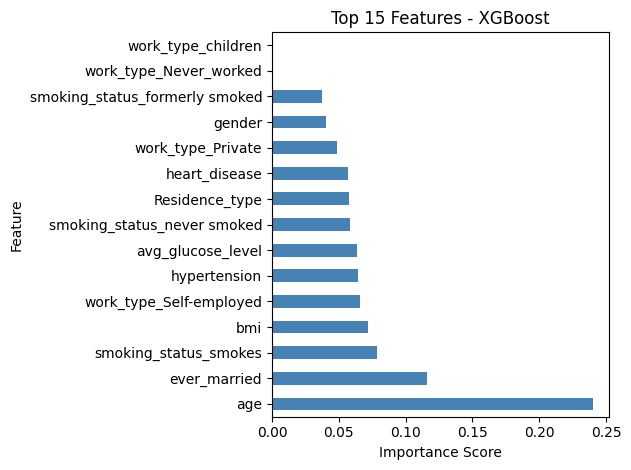

In [54]:
# Feature importance — how much each feature contributed across all trees
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Important Features (XGBoost):")
print(xgb_importance.head(10).to_string(index=False))

xgb_importance.head(15).plot(kind='barh', x='Feature', y='Importance', color='steelblue', legend=False)
plt.title('Top 15 Features - XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# 6. Model Comparison

All three models are evaluated side by side on the held-out test set. Because upsampling was applied correctly, only to the training set after splitting, these results reflect genuine generalisation performance on unseen data.

              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.726206   0.132479 0.815789  0.227941
                KNN  0.877445   0.075758 0.131579  0.096154
            XGBoost  0.940026   0.300000 0.157895  0.206897


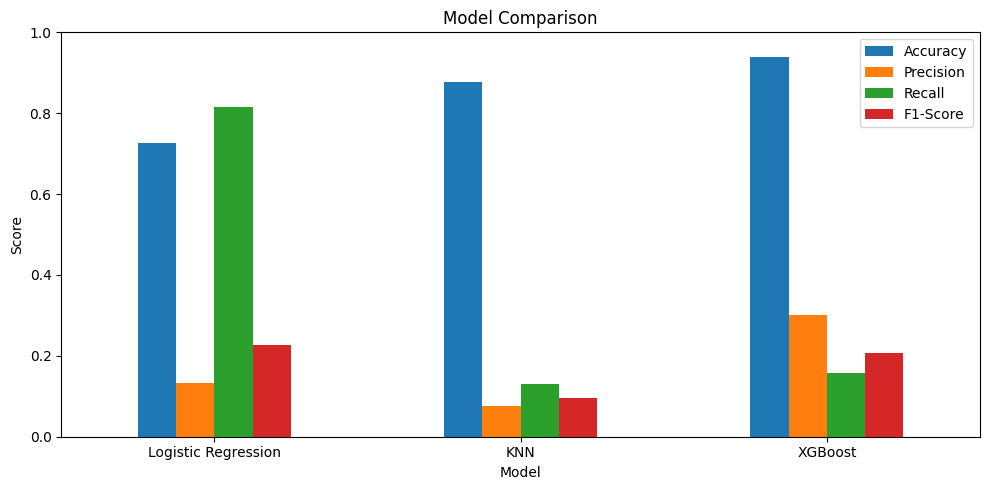

Best Model (by F1-Score): Logistic Regression


In [60]:
# Collect all test metrics into a single comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_test_pred_lr),
        accuracy_score(y_test, y_test_pred_knn),
        accuracy_score(y_test, y_test_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_test_pred_lr, zero_division=0),
        precision_score(y_test, y_test_pred_knn, zero_division=0),
        precision_score(y_test, y_test_pred_xgb, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_test_pred_lr, zero_division=0),
        recall_score(y_test, y_test_pred_knn, zero_division=0),
        recall_score(y_test, y_test_pred_xgb, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_test_pred_lr, zero_division=0),
        f1_score(y_test, y_test_pred_knn, zero_division=0),
        f1_score(y_test, y_test_pred_xgb, zero_division=0)
    ]
})

print(comparison.to_string(index=False))

# Bar chart to visually compare all metrics across models
comparison.plot(kind='bar', x='Model', figsize=(10, 5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Best model by F1-Score
best = comparison.loc[comparison['F1-Score'].idxmax(), 'Model']
print(f"Best Model (by F1-Score): {best}")

# 7. Overfitting Analysis

A large gap between training and test accuracy means the model memorised the training data rather than learning general patterns. A gap below 0.10 is considered acceptable.

In [61]:
# Compare train vs test accuracy — a large gap signals overfitting,
print("OVERFITTING ANALYSIS (Train Accuracy - Test Accuracy):")

for name, y_tr, y_te in [
    ("Logistic Regression", y_train_pred_lr,  y_test_pred_lr),
    ("KNN",                 y_train_pred_knn, y_test_pred_knn),
    ("XGBoost",             y_train_pred_xgb, y_test_pred_xgb)
]:
    train_acc = accuracy_score(y_train, y_tr)
    test_acc  = accuracy_score(y_test, y_te)
    gap       = train_acc - test_acc
    print(f"  {name:<22} {train_acc:.4f} - {test_acc:.4f} = {gap:.4f}")

print("A gap > 0.10 indicates overfitting.")

OVERFITTING ANALYSIS (Train Accuracy - Test Accuracy):
  Logistic Regression    0.7827 - 0.7262 = 0.0565
  KNN                    1.0000 - 0.8774 = 0.1226
  XGBoost                1.0000 - 0.9400 = 0.0600
A gap > 0.10 indicates overfitting.


Logistic Regression shows the healthiest gap (0.057), comfortably within the acceptable range. XGBoost's gap (0.060) is also acceptable, though its perfect training accuracy warrants monitoring. KNN's gap (0.123) exceeds the 0.10 threshold, confirming the overfitting observed in its near-zero stroke recall on the test set.

# 8. Cross-Validation (5-Fold)

Cross-validation splits the training data into 5 parts, trains on 4 and tests on 1, rotating through all combinations. This checks whether each model performs consistently across different subsets of the data — a low standard deviation means stable results.

In [59]:
from sklearn.model_selection import cross_val_score

# Run 5-fold CV on each model using the appropriate data
for model_name, model, X in [
    ('Logistic Regression', lr_model,  X_train_scaled),
    ('KNN',                 knn_model, X_train_scaled),
    ('XGBoost',             xgb_model, X_train)
]:
    cv_scores = cross_val_score(model, X, y_train, cv=5, scoring='f1')
    print(f"{model_name}:")
    print(f"  Fold Scores: {[f'{s:.4f}' for s in cv_scores]}")
    print(f"  Mean: {cv_scores.mean():.4f}, Std: {cv_scores.std():.4f}")
    stability = "stable" if cv_scores.std() < 0.05 else "some variance - monitor closely"
    print(f"  Verdict: {stability}")

Logistic Regression:
  Fold Scores: ['0.7955', '0.7862', '0.7986', '0.7923', '0.7905']
  Mean: 0.7926, Std: 0.0043
  Verdict: stable
KNN:
  Fold Scores: ['0.9505', '0.9565', '0.9426', '0.9611', '0.9625']
  Mean: 0.9546, Std: 0.0074
  Verdict: stable
XGBoost:
  Fold Scores: ['0.9770', '0.9827', '0.9799', '0.9791', '0.9862']
  Mean: 0.9810, Std: 0.0032
  Verdict: stable


CV scores should be interpreted carefully here: cross-validation ran on the **balanced training set** (upsampled), not the real-world class distribution. This explains the high CV F1-scores for KNN (0.955) and XGBoost (0.981) — they reflect performance on near-equal class splits, not the 95:5 imbalance in the actual test set. Logistic Regression's CV F1 of 0.793 is more representative of its real test behaviour. Test set results are the reliable measure of true generalisation for this dataset.

# 9. Summary & Key Findings

## Model Performance Summary

| Model | Test Accuracy | Test Recall | Test F1 | Overfitting Gap | Recommended? |
|-------|:---:|:---:|:---:|:---:|:---:|
| Logistic Regression | 0.7262 | **0.8158** | 0.2279 | 0.057 | Yes, best recall |
| KNN | 0.8774 | 0.1316 | 0.0962 | 0.123  |  No, poor recall, overfits |
| XGBoost | 0.9400 | 0.1579 | 0.2069 | 0.060  |  Partial, best precision, low recall |

## Top Stroke Risk Drivers

Based on Logistic Regression coefficients and XGBoost feature importance:

1. **Age** (LR coef: 1.89, XGB importance: 0.240) — by far the strongest predictor in both models.
2. **Hypertension** (LR coef: 0.45, XGB importance: 0.064) — directly elevates stroke risk.
3. **Heart disease** (LR coef: 0.33, XGB importance: 0.057) — a known comorbidity linked to stroke.
4. **Average glucose level** (LR coef: 0.25, XGB importance: 0.064) — high blood glucose is a well-established risk factor.

## Key Insights

- **Recall is the priority metric:** The test set contains only 38 stroke cases out of 767 patients (5%). In this context, missing a stroke (false negative) is clinically far more dangerous than a false alarm. Logistic Regression's recall of 0.82 makes it the strongest model by this measure.
- **High accuracy is misleading here:** KNN (87.7%) and XGBoost (94.0%) achieve high accuracy by predicting the majority class well. Both catch fewer than 20% of actual stroke cases — not acceptable for a medical screening tool.
- **CV scores do not reflect real-world performance:** Cross-validation ran on the balanced training set. KNN and XGBoost's high CV F1-scores (0.955, 0.981) reflect balanced-class conditions, not the 95:5 test distribution. Test set metrics are the authoritative measure.
- **KNN overfits:** A train-test gap of 0.123 exceeds the 0.10 threshold, and its stroke recall of 0.13 confirms it has not learned generalisable patterns for the minority class.
- **Recommendation:** Deploy Logistic Regression. It is the only model that reliably detects stroke cases (recall 0.82), is interpretable, and generalises cleanly. XGBoost's higher precision (0.30) could complement it in a two-stage system — use Logistic Regression to flag candidates, then XGBoost to filter — but standalone, Logistic Regression is the right choice.